# **Data processing**

### Libraries

In [10]:
import chess
import chess.pgn
import random
import csv
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data generation

In [11]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from bot import LowEloBot, Stockfish
from engine import Engine

In [3]:
def simulate_game(max_moves=80):
    engine = Engine()
    board = engine.board
    game = chess.pgn.Game()
    node = game

    # Instantiate LowEloBot with the chess engine (board)
    bot = LowEloBot(engine)

    for _ in range(max_moves):
        if board.is_game_over():
            break
        move = bot.predict()  # Get bot's move using predict
        board.push(move)
        node = node.add_variation(move)

    game.headers["Result"] = board.result()
    return game

def generate_games(num_games=100, out_file="test_positions.pgn"):
    with open(out_file, "w") as f:
        for _ in tqdm(range(num_games), desc="Generating games"):
            game = simulate_game()
            f.write(str(game) + "\n\n")

In [4]:
generate_games(num_games=10000)

Generating games:   0%|          | 0/10000 [00:00<?, ?it/s]

Generating games: 100%|██████████| 10000/10000 [04:06<00:00, 40.61it/s]


### Extracting positions

In [5]:
# === Config ===
NUM_POSITIONS = 10000

TARGET = {
    "opening": int(0.3 * NUM_POSITIONS),
    "middlegame": int(0.6 * NUM_POSITIONS),
    "endgame": int(0.1 * NUM_POSITIONS),
}

# === Helper Functions ===
def determine_game_phase_by_move_count(move_number):
    """Classify the phase of the game based on move count."""
    if move_number <= 15:  # Opening phase (first 10-15 moves)
        return "opening"
    elif move_number <= 40:  # Middlegame phase (moves 16-40)
        return "middlegame"
    else:  # Endgame phase (after move 40)
        return "endgame"

def extract_random_positions(game, num_positions=50000):
    board = chess.Board()
    data = []
    all_moves = list(game.mainline_moves())

    # Separate positions by phase
    opening_positions = []
    middlegame_positions = []
    endgame_positions = []

    # Classify positions by game phase based on move count
    for move_number, move in enumerate(all_moves):
        if board.is_legal(move):
            board.push(move)

        fen = board.fen()
        
        # Determine the game phase based on move count
        phase = determine_game_phase_by_move_count(move_number)
        
        # Store the position based on its phase
        next_move = None
        if move_number + 1 < len(all_moves):
            next_move = all_moves[move_number + 1].uci()

        if phase == "opening" and len(opening_positions) < TARGET["opening"]:
            opening_positions.append([fen, next_move])
        elif phase == "middlegame" and len(middlegame_positions) < TARGET["middlegame"]:
            middlegame_positions.append([fen, next_move])
        elif phase == "endgame" and len(endgame_positions) < TARGET["endgame"]:
            endgame_positions.append([fen, next_move])

    # Now combine the positions, ensuring we have a variety from each phase
    data.extend(opening_positions)
    data.extend(middlegame_positions)
    data.extend(endgame_positions)

    # If not enough positions, fill in randomly from available positions
    if len(data) < num_positions:
        # Shuffle and add more positions if necessary
        all_positions = opening_positions + middlegame_positions + endgame_positions
        random.shuffle(all_positions)
        data.extend(all_positions[:num_positions - len(data)])

    return data[:num_positions]  # Ensure we only return the required number of positions

def write_to_csv(data, output_file):
    """Write extracted positions to CSV."""
    headers = ["fen", "next_move"]
    with open(output_file, mode="w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(headers)  # Write header
        writer.writerows(data)  # Write data rows
    print(f"Data has been written to {output_file}")


In [6]:
# === Main Process ===
with open("data/test_positions.pgn", encoding="utf-8") as pgn_file:
    game_data = []
    total_games = 10000  # Adjust this based on how many games you want to process
    pgn_file.seek(0)  # Reset the file pointer to the beginning
    
    # Read the entire PGN file and process each game with tqdm progress bar
    with tqdm(total=total_games, desc="Processing games") as pbar:
        while True:
            game = chess.pgn.read_game(pgn_file)
            if game is None:
                break
            # Extract random positions from the current game
            game_data.extend(extract_random_positions(game))
            pbar.update(1)  # Update progress bar

    # Write the extracted data to CSV
    write_to_csv(game_data, output_file="data/test_positions.csv")

Processing games: 100%|██████████| 10000/10000 [01:19<00:00, 125.68it/s]


Data has been written to data/test_positions.csv


In [12]:
# === Config ===
NUM_POSITIONS = 50000
POSITIONS_PER_MOVE_COUNT = 1000  # 1000 positions per move count

# === Helper Function ===
def extract_positions_by_move_count(df, num_positions=50000, positions_per_move_count=1000):
    # Initialize a dictionary to store positions by move count
    move_counts = {}

    # Group positions by move count (from the "fen" column)
    for index, row in df.iterrows():
        # Extract move number from the FEN string (move number is second to last in the FEN string)
        move_number = int(row['fen'].split()[-2])

        # Add position to the corresponding move number group
        if move_number not in move_counts:
            move_counts[move_number] = []
        move_counts[move_number].append([row['fen'], row['next_move']])

    # Now, collect 1000 positions for each move count, ensuring we have 50,000 positions in total
    selected_positions = []
    
    # Use tqdm to show progress for collecting positions
    for move_number in tqdm(range(1, 101), desc="Selecting Positions by Move Count", unit="move"):  # Assuming move numbers from 1 to 100
        if move_number in move_counts:
            positions = move_counts[move_number]
            random.shuffle(positions)  # Shuffle to select randomly
            selected_positions.extend(positions[:positions_per_move_count])

    # If we don't have enough positions, fill the remaining slots by shuffling the existing data
    if len(selected_positions) < num_positions:
        all_positions = [pos for move_list in move_counts.values() for pos in move_list]
        random.shuffle(all_positions)
        selected_positions.extend(all_positions[:num_positions - len(selected_positions)])

    # Ensure we have exactly the desired number of positions
    return selected_positions[:num_positions]

# === Main Process ===
df = pd.read_csv("data/test_positions.csv")

# Extract the positions based on move count
selected_data = extract_positions_by_move_count(df)

# Write the extracted positions to a new CSV
def write_to_csv(data, output_file):
    headers = ["fen", "next_move"]
    with open(output_file, mode="w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(headers)  # Write header
        writer.writerows(data)  # Write data rows
    print(f"Data has been written to {output_file}")

# Output file
write_to_csv(selected_data, "data/test_positions.csv")

Selecting Positions by Move Count: 100%|██████████| 100/100 [00:00<00:00, 294.59move/s]


Data has been written to data/test_positions.csv


Then we visualize the move repartitions for the extracted positions.

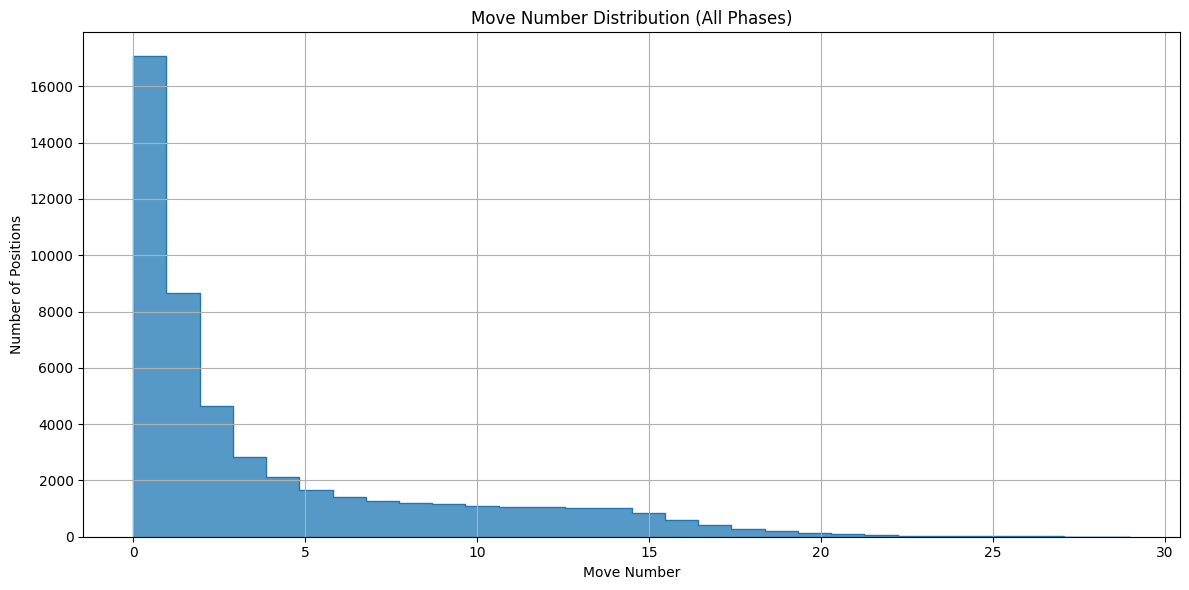

In [4]:
# === Reading Data and Processing ===
df = pd.read_csv("data/lowELO_dataset.csv")

# Extract move number from the FEN string (the number is the last part of the FEN)
df["move_number"] = df["fen"].apply(lambda fen: int(fen.split()[-2]))

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x="move_number", element="step", common_norm=False, bins=30)
plt.title("Move Number Distribution (All Phases)")
plt.xlabel("Move Number")
plt.ylabel("Number of Positions")
plt.grid(True)
plt.tight_layout()
plt.show()


### Good or bad move ?

In [3]:
# --- Define helper functions ---

# Material evaluation function
def material_count(board):
    piece_values = {
        chess.PAWN: 1,
        chess.KNIGHT: 3,
        chess.BISHOP: 3,
        chess.ROOK: 5,
        chess.QUEEN: 9,
        chess.KING: 0
    }
    count = 0
    for piece_type, value in piece_values.items():
        count += len(board.pieces(piece_type, chess.WHITE)) * value
        count -= len(board.pieces(piece_type, chess.BLACK)) * value
    return count

# Number of legal moves
def num_legal_moves(board):
    return board.legal_moves.count()

# Is the side to move in check
def is_in_check(board):
    return int(board.is_check())

# Center control (e4, d4, e5, d5)
def center_control(board):
    center_squares = [chess.E4, chess.D4, chess.E5, chess.D5]
    count = 0
    for square in center_squares:
        attackers = board.attackers(board.turn, square)
        count += len(attackers)
    return count

# Extract features from a FEN
def extract_features(fen):
    board = chess.Board(fen)
    features = {
        "material_diff": material_count(board),
        "num_legal_moves": num_legal_moves(board),
        "is_in_check": is_in_check(board),
        "center_control": center_control(board)
    }
    return features

In [4]:
# --- Main script ---

# Load the data
data = pd.read_csv("data/lowELO_dataset.csv")

# Prepare new columns
data["move_type"] = None  # Target: 1 good / 0 bad
data["material_diff"] = None
data["num_legal_moves"] = None
data["is_in_check"] = None
data["center_control"] = None

# Evaluate moves and extract features
for index, row in tqdm(data.iterrows(), total=len(data), desc="Processing positions", unit="row"):
    fen = row["fen"]
    next_move = row["next_move"]
    
    if not isinstance(next_move, str):
        continue  # Skip if move is not valid
    
    board = chess.Board(fen)
    prev_material = material_count(board)
    is_white_turn = board.turn == chess.WHITE
    
    # Extract features before the move
    features = extract_features(fen)
    for key, value in features.items():
        data.at[index, key] = value

    # Evaluate the move
    move = chess.Move.from_uci(next_move)
    if move in board.legal_moves:
        board.push(move)
        new_material = material_count(board)
        
        if (is_white_turn and new_material > prev_material) or (not is_white_turn and new_material < prev_material):
            data.at[index, "move_type"] = 1  # Good move
        else:
            data.at[index, "move_type"] = 0  # Bad move

# Drop rows where move_type could not be determined
data = data.dropna(subset=['move_type'])

# Save processed dataset
data.to_csv("data/lowELO_evaluated.csv", index=False)

print("✅ Evaluation complete. Dataset with features saved!")

Processing positions: 100%|██████████| 50000/50000 [00:19<00:00, 2618.23row/s]


✅ Evaluation complete. Dataset with features saved!


In [5]:
# Read the newly created CSV file
data = pd.read_csv("data/lowELO_evaluated.csv")

# Count the number of good (1) and bad (0) moves in the 'move_type' column
move_counts = data['move_type'].value_counts()

# Display the results
print(f"Good moves (1): {move_counts.get(1, 0)}")
print(f"Bad moves (0): {move_counts.get(0, 0)}")

Good moves (1): 12534
Bad moves (0): 35682
